# Fine-tuning de Whisper Small sur le Fongbé

## 1. Installation des dépendances

In [ ]:
# !pip install transformers datasets evaluate jiwer accelerate librosa soundfile torchaudio -q

## 2. Imports et détection du GPU

In [ ]:
import os, re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import librosa
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, List, Union

from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)
from datasets import Dataset
from evaluate import load

#  Désactivaction du multiprocessing tokenizers
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   

# Détection automatique GPU 
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU NVIDIA détecté : {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print("GPU Apple Silicon (MPS) détecté")
else:
    device = "cpu"
    print("CPU uniquement — le fine-tuning sera lent")

print(f"Device sélectionné : {device}")

GPU Apple Silicon (MPS) détecté
Device sélectionné : mps


## 3. Définition des chemins

In [ ]:
BASE_DIR   = "../data/fine_tuning_ASR"
LAB_DIR    = os.path.join(BASE_DIR, "fongbe_speech_audio_files/lab")
WAV_DIR    = os.path.join(BASE_DIR, "fongbe_speech_audio_files/wav")
META_CSV   = os.path.join(BASE_DIR, "fongbe_speech_dataset_metadata.csv")
OUTPUT_CSV = os.path.join(BASE_DIR, "dataset_60min.csv")
OUTPUT_MODEL_DIR = os.path.join(BASE_DIR, "whisper-small-fongbe")

# Vérification
for nom, chemin in [("lab", LAB_DIR), ("wav", WAV_DIR), ("metadata", META_CSV)]:
    statut = " OK" if os.path.exists(chemin) else " INTROUVABLE"
    print(f"  {nom:<12} : {statut}  ({chemin})")

  lab          :  OK  (./Fongbe_Speech_Dataset/fongbe_speech_audio_files/lab)
  wav          :  OK  (./Fongbe_Speech_Dataset/fongbe_speech_audio_files/wav)
  metadata     :  OK  (./Fongbe_Speech_Dataset/fongbe_speech_dataset_metadata.csv)


## 4. Chargement et nettoyage du metadata
Pour chaque ligne, on lit le fichier `.txt` correspondant pour récupérer la transcription.

In [5]:
df = pd.read_csv(
    META_CSV,
    header=None,
    names=["speaker_id", "gender", "age", "language", "txt_file", "wav_file"]
)
df = df[df["speaker_id"] != "speaker ID"].reset_index(drop=True)
print(f"Enregistrements chargés : {len(df)}")

def lire_transcription(txt_filename):
    path = os.path.join(LAB_DIR, txt_filename)
    try:
        with open(path, "r", encoding="utf-8") as f:
            return f.read().strip()
    except FileNotFoundError:
        return None

df["transcription"] = df["txt_file"].apply(lire_transcription)
df["audio_path"]    = df["wav_file"].apply(lambda f: os.path.join(WAV_DIR, f))
df_clean = df.dropna(subset=["transcription"]).copy()
df_clean = df_clean[["audio_path", "transcription", "gender", "age", "speaker_id"]]

print(f"Après nettoyage : {len(df_clean)} enregistrements valides")
print(df_clean.head(3).to_string())

Enregistrements chargés : 3179
Après nettoyage : 3179 enregistrements valides
                                                                                                                                    audio_path                                 transcription  gender age speaker_id
0  ./Fongbe_Speech_Dataset/fongbe_speech_audio_files/wav/82_fongbe_71ac57a5-79d5-4658-a205-8e362d80ba2f_for_validation_2022-04-02-05-28-53.wav  gblo ali nε ɔ vi tɔn sin ta klo bo ci gbεwun    male  30          5
1  ./Fongbe_Speech_Dataset/fongbe_speech_audio_files/wav/72_fongbe_1aac4be0-f3f6-4333-be0a-ace47f042db3_for_validation_2022-03-17-03-59-45.wav                  un na do atan ɔ va xuna ɔ lo  female  35          2
2  ./Fongbe_Speech_Dataset/fongbe_speech_audio_files/wav/71_fongbe_4f1a2555-6038-437a-8a8e-a8bb8407dc98_for_validation_2022-03-06-17-15-46.wav     nusunnu ɔ sin wan gba kpe fi bi ahan ɔ sa    male  33          3


## 5. Calcul des durées et sélection ≤ 30 minutes
Le dataset complet peut faire plusieurs heures. On sélectionne **30 minutes maximum** de façon aléatoire reproductible (seed=42), en garantissant un bon mélange de locuteurs.

> **Énoncé** : *« même 30 minutes suffisent »* — `TARGET_MIN = 30`

In [ ]:
from tqdm import tqdm

#  Calcul des durées 
print("Calcul des durées...")
df_clean["duration_sec"] = [
    librosa.get_duration(path=p) for p in tqdm(df_clean["audio_path"])
]

total_min = df_clean["duration_sec"].sum() / 60
print(f"\nDataset complet :")
print(f"  Audios          : {len(df_clean)}")
print(f"  Durée totale    : {total_min:.1f} minutes")
print(f"  Durée moyenne   : {df_clean['duration_sec'].mean():.2f}s")
print(f"  Durée min/max   : {df_clean['duration_sec'].min():.2f}s / {df_clean['duration_sec'].max():.2f}s")

#  Sélection du nombre de minutes d'audio
TARGET_MIN = 30          
TARGET_SEC = TARGET_MIN * 60

# Mélange reproductible puis accumulation des durées
df_shuffled = df_clean.sample(frac=1, random_state=42).reset_index(drop=True)
cumsum      = df_shuffled["duration_sec"].cumsum()
df_selected = df_shuffled[cumsum <= TARGET_SEC].copy()

duree_sel = df_selected["duration_sec"].sum()
duree_min = duree_sel / 60
duree_sec_reste = duree_sel % 60 if False else None 

print(f"\n{'='*50}")
print(f"  SÉLECTION FINALE — objectif : ≤ {TARGET_MIN} minutes")
print(f"{'='*50}")
print(f"  Audios sélectionnés : {len(df_selected)}")
print(f"  Durée totale        : {duree_min:.1f} minutes ({duree_sel:.0f}s)")
print(f"  Durée / audio (moy) : {df_selected['duration_sec'].mean():.2f}s")
print(f"  Locuteurs           : {df_selected['speaker_id'].nunique()} différents")
print(f"  Répartition genre   :")
for genre, count in df_selected["gender"].value_counts().items():
    pct = count / len(df_selected) * 100
    print(f"    {genre} : {count} ({pct:.0f}%)")

# Vérification que l'objectif est respecté
assert duree_min <= TARGET_MIN + 0.1, f"Dépassement : {duree_min:.1f} min > {TARGET_MIN} min"
print(f"\n Objectif respecté : {duree_min:.1f} min ≤ {TARGET_MIN} min")

df_exclus = df_shuffled[cumsum > TARGET_SEC]
if len(df_exclus) > 0:
    print(f"\n  Audios exclus (dépassement) : {len(df_exclus)}")
    premier_exclus = df_exclus.iloc[0]
    print(f"  Premier exclus : {Path(premier_exclus['audio_path']).name} "
          f"({premier_exclus['duration_sec']:.1f}s)")

df_selected.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n Dataset sauvegardé : {OUTPUT_CSV}")

Calcul des durées...


100%|██████████| 3179/3179 [00:01<00:00, 2418.90it/s]



Dataset complet :
  Audios          : 3179
  Durée totale    : 306.8 minutes
  Durée moyenne   : 5.79s
  Durée min/max   : 1.86s / 51.40s

  SÉLECTION FINALE — objectif : ≤ 30 minutes
  Audios sélectionnés : 307
  Durée totale        : 29.9 minutes (1796s)
  Durée / audio (moy) : 5.85s
  Locuteurs           : 13 différents
  Répartition genre   :
    female : 214 (70%)
    male : 93 (30%)

✅ Objectif respecté : 29.9 min ≤ 30 min

  Audios exclus (dépassement) : 2872
  Premier exclus : 81_fongbe_6931afc0-d1b7-480a-a1cf-8a81c9f796f1_for_validation_2022-03-09-23-24-13.wav (6.7s)

✅ Dataset sauvegardé : ./Fongbe_Speech_Dataset/dataset_60min.csv


## 6. Chargement du Processor Whisper
Le processor regroupe le feature extractor (audio → Log-Mel 80 bandes) et le tokenizer (texte → tokens).

In [7]:
processor = WhisperProcessor.from_pretrained(
    "openai/whisper-small",
    language="French",
    task="transcribe"
)
print(" Processor chargé")
print(f"   Sampling rate : {processor.feature_extractor.sampling_rate} Hz")
print(f"   Vocab size    : {processor.tokenizer.vocab_size}")

 Processor chargé
   Sampling rate : 16000 Hz
   Vocab size    : 50258


## 7. Évaluation baseline — Whisper brut avant fine-tuning
On mesure le WER du modèle original sur notre set de test fongbé.
Ce score sert de référence pour mesurer l'amélioration du fine-tuning.

In [ ]:
wer_metric = load("wer")

# ── Dataset et split 
df_sel        = pd.read_csv(OUTPUT_CSV)
dataset_full  = Dataset.from_pandas(df_sel)
dataset_split = dataset_full.train_test_split(test_size=0.2, seed=42)
test_set      = dataset_split["test"]
train_set_raw = dataset_split["train"]
print(f"Train : {len(train_set_raw)} exemples  |  Test : {len(test_set)} exemples")

# ── Modèle baseline sur GPU 
model_baseline = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model_baseline.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="french", task="transcribe"
)
model_baseline = model_baseline.to(device)
model_baseline.eval()
print(f"Modèle baseline sur : {next(model_baseline.parameters()).device}")

#  Résolution chemin audio 
def resoudre(chemin_csv):
    """Retourne le chemin Path vers le fichier audio, None si introuvable."""
    p = Path(str(chemin_csv))
    if p.exists():
        return p
    # Essayer avec WAV_DIR
    nom = p.name
    alt = Path(WAV_DIR) / nom
    if alt.exists():
        return alt
    return None

#  Transcription
print("\nTranscription baseline en cours...")
predictions_baseline = []
references_test      = []

for i, exemple in enumerate(test_set.to_list()):
    chemin = resoudre(exemple["audio_path"])
    ref    = str(exemple.get("transcription", ""))
    references_test.append(ref)

    if chemin is None:
        print(f"  [{i+1:>3}]  Audio introuvable : {exemple['audio_path']}")
        predictions_baseline.append("")
        continue

    try:
        audio, _ = librosa.load(str(chemin), sr=16000, mono=True)
        inputs   = processor(
            audio, sampling_rate=16000, return_tensors="pt"
        ).input_features.to(device)

        with torch.no_grad():
            ids = model_baseline.generate(inputs)

        pred = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()

    except RuntimeError as e:
        # Fallback CPU si l'opération n'est pas supportée sur MPS
        print(f"  [{i+1:>3}]   MPS fallback CPU")
        model_baseline.to("cpu")
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt").input_features
        with torch.no_grad():
            ids = model_baseline.generate(inputs)
        pred = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
        model_baseline.to(device)   # remettre sur GPU pour les suivants

    predictions_baseline.append(pred)
    print(f"  [{i+1:>3}/{len(test_set)}]  {chemin.name}  →  {pred[:70]}")

#  WER baseline 
paires_ok    = [(r, h) for r, h in zip(references_test, predictions_baseline) if r.strip()]
wer_baseline = wer_metric.compute(
    predictions=[h for r, h in paires_ok],
    references =[r for r, h in paires_ok]
)

print(f"\n{'='*50}")
print(f"  WER BASELINE (avant fine-tuning) : {wer_baseline:.2%}")
print(f"{'='*50}")

print("\nExemples :")
for i in range(min(3, len(predictions_baseline))):
    print(f"  Réf. : {references_test[i]}")
    print(f"  Pred : {predictions_baseline[i]}")
    print()

# Sauvegarder pour ne pas perdre si kernel redémarre
json.dump(
    {"wer_baseline": wer_baseline, "predictions": predictions_baseline,
     "references": references_test},
    open(os.path.join(BASE_DIR, "baseline_results.json"), "w"), ensure_ascii=False, indent=2
)
print(" Résultats baseline sauvegardés")

Train : 245 exemples  |  Test : 62 exemples
Modèle baseline sur : mps:0

Transcription baseline en cours...


Due to a bug fix in https://github.com/huggingface/transformers/pull/28687 transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English.This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`.
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  [  1/62]  82_fongbe_0e15543d-3c62-4c7e-b73b-77b411831573_for_validation_2022-03-20-03-39-30.wav  →  e ging ging nen bero do, e cambia mi do hwe ten to chen nan waddi.
  [  2/62]  91_fongbe_ef1d72ee-1a04-42ed-a974-1d7b8559e264_for_validation_2022-03-22-01-17-21.wav  →  Egoi Erengão, gondom
  [  3/62]  89_fongbe_2b24a208-2e8f-41ba-b7c3-bae1261a0624_for_validation_2022-03-31-01-04-52.wav  →  ន្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្
  [  4/62]  71_fongbe_43bf952d-2ad6-4cc9-a26f-b9dc0b4615c8_for_validation_2022-03-23-07-15-42.wav  →  ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន 
  [  5/62]  81_fongbe_78f854d1-0541-4a26-950d-dcc196bfad46_for_validation_2022-03-28-12-57-33.wav  →  E yi benuku e gudu we matye lebi
  [  6/62]  71_fongbe_7a82dc74-905a-40e9-aebd-aad2e83a9760_for_validation_2022-03-18-08-48-02.wav  →  I'm not a good person. I'm not good.
  [  7/62]  90_fongbe_a12c4fc6-3911-4b55-a76c-840dcba496e5_for_validation_2022-03-14-13-

## 8. Préparation des features pour le fine-tuning
Conversion audio → Log-Mel Spectrogram (80 filtres Whisper) + tokenisation des transcriptions.

In [9]:
def prepare_dataset(batch):
    chemin = resoudre(batch["audio_path"])
    if chemin is None:
        return None
    audio, _ = librosa.load(str(chemin), sr=16000, mono=True)

    # Log-Mel Spectrogram — 80 filtres, config Whisper
    batch["input_features"] = processor.feature_extractor(
        audio, sampling_rate=16000
    ).input_features[0]

    # Tokenisation de la transcription de référence
    batch["labels"] = processor.tokenizer(
        batch["transcription"]
    ).input_ids
    return batch

COLS_A_SUPPRIMER = [c for c in ["audio_path","transcription","gender","age",
                                  "speaker_id","duration_sec","__index_level_0__"]
                    if c in train_set_raw.column_names]

print("Extraction features train...")
train_prepared = train_set_raw.map(
    prepare_dataset,
    remove_columns=COLS_A_SUPPRIMER,
)

COLS_TEST = [c for c in COLS_A_SUPPRIMER if c in test_set.column_names]
print("Extraction features test...")
test_prepared = test_set.map(
    prepare_dataset,
    remove_columns=COLS_TEST,
)

# Filtrer les None (audio manquant)
train_prepared = train_prepared.filter(lambda x: x["input_features"] is not None)
test_prepared  = test_prepared.filter(lambda x: x["input_features"] is not None)

print(f"\n✅ Features extraites")
print(f"   Train : {len(train_prepared)} exemples")
print(f"   Test  : {len(test_prepared)}  exemples")

Extraction features train...


Map:   0%|          | 0/245 [00:00<?, ? examples/s]

Extraction features test...


Map:   0%|          | 0/62 [00:00<?, ? examples/s]

Filter:   0%|          | 0/245 [00:00<?, ? examples/s]

Filter:   0%|          | 0/62 [00:00<?, ? examples/s]


✅ Features extraites
   Train : 245 exemples
   Test  : 62  exemples


## 9. Data collator et métrique

In [10]:
@dataclass
class DataCollatorSpeechSeq2Seq:
    """
    Gère le padding des batchs pour Whisper :
    - input_features : padde à 3000 trames (30s)
    - labels         : padde avec -100 (ignorés dans la cross-entropy)
    """
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]):
        # Padding des features audio
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors="pt"
        )
        # Padding des labels
        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch   = self.processor.tokenizer.pad(
            label_features, return_tensors="pt"
        )
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        # Supprimer le token BOS si présent en début de séquence
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]
        batch["labels"] = labels
        return batch


data_collator = DataCollatorSpeechSeq2Seq(processor=processor)


def compute_metrics(pred):
    """WER calculé à chaque étape d'évaluation pendant l'entraînement."""
    pred_ids  = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str  = processor.tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = processor.tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    # Filtrer les références vides
    paires = [(r, h) for r, h in zip(label_str, pred_str) if r.strip()]
    if not paires:
        return {"wer": 1.0}
    return {"wer": wer_metric.compute(
        predictions=[h for r, h in paires],
        references =[r for r, h in paires]
    )}


print("✅ Data collator et métrique définis")

✅ Data collator et métrique définis


## 10. Fine-tuning sur GPU
**Paramètres clés** :
- `fp16=True` sur CUDA, `bf16=False` sur MPS (non supporté)
- `no_cuda=False` — laisse HuggingFace choisir le device
- `gradient_checkpointing=True` — réduit la RAM GPU
- 50 steps suffisent pour le bonus (≈ 5–10 min sur M3 Pro MPS)

In [ ]:
# Configuration selon le device 
use_fp16 = torch.cuda.is_available()     # fp16 uniquement sur NVIDIA
use_bf16 = False                          # bf16 non supporté sur MPS
use_no_cuda = (device != "cuda")          # True sur MPS et CPU

print(f"Configuration GPU :")
print(f"  device     = {device}")
print(f"  fp16       = {use_fp16}  (NVIDIA uniquement)")
print(f"  bf16       = {use_bf16}")
print(f"  no_cuda    = {use_no_cuda}")

# Modèle pour le fine-tuning 
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small")
model.config.forced_decoder_ids = None  
model.config.suppress_tokens    = []
model.config.use_cache          = False 
model = model.to(device)
print(f"\nModèle chargé sur : {next(model.parameters()).device}")

# Arguments d'entraînement 
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_MODEL_DIR,

    # Batch réduit 
    per_device_train_batch_size=2,     # ← réduit de 4 à 2
    gradient_accumulation_steps=2,     # ← réduit de 4 à 2 (batch effectif = 4)
    per_device_eval_batch_size=2,      # ← réduit de 4 à 2

    learning_rate=1e-5,
    warmup_steps=10,                   # ← réduit de 20 à 10
    max_steps=50,

    # Précision
    fp16=False,
    bf16=False,

    # Désactivaction de gradient_checkpointing sur MPS 
    gradient_checkpointing=False,      # ← False sur MPS

    # Évaluation 
    eval_strategy="steps",
    eval_steps=25,
    save_steps=25,
    logging_steps=5,

    predict_with_generate=True,
    generation_max_length=225,

    load_best_model_at_end=True,
    metric_for_best_model="wer",
    greater_is_better=False,

    report_to=["tensorboard"],
    dataloader_num_workers=0,
    no_cuda=True,                      # MPS n'est pas CUDA
    push_to_hub=False,
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_prepared,
    eval_dataset=test_prepared,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    tokenizer=processor.feature_extractor,
)

print(f"\nTrain : {len(train_prepared)} exemples")
print(f"Test  : {len(test_prepared)}  exemples")
print(f"max_steps=50 → durée estimée :")
print(f"  M3 Pro MPS  : ~8–12 min")
print(f"  NVIDIA GPU  : ~2–4 min")
print(f"  CPU seul    : ~30–45 min")
print("\nLancement du fine-tuning...")
trainer.train()

# Sauvegarde du  meilleur modèle 
trainer.save_model(OUTPUT_MODEL_DIR)
processor.save_pretrained(OUTPUT_MODEL_DIR)
print(f"\n Modèle sauvegardé → {OUTPUT_MODEL_DIR}")

Configuration GPU :
  device     = mps
  fp16       = False  (NVIDIA uniquement)
  bf16       = False
  no_cuda    = True


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /openai/whisper-small/resolve/main/config.json (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x356a41890>: Failed to establish a new connection: [Errno 8] nodename nor servname provided, or not known'))"), '(Request ID: b5e3ccf6-7d3a-4bf6-9038-eb53a96eff7c)')' thrown while requesting HEAD https://huggingface.co/openai/whisper-small/resolve/main/config.json
Retrying in 1s [Retry 1/5].
max_steps is given, it will override any value given in num_train_epochs



Modèle chargé sur : mps:0

Train : 245 exemples
Test  : 62  exemples
max_steps=50 → durée estimée :
  M3 Pro MPS  : ~8–12 min
  NVIDIA GPU  : ~2–4 min
  CPU seul    : ~30–45 min

Lancement du fine-tuning...


  0%|          | 0/50 [00:00<?, ?it/s]

{'loss': 4.8466, 'grad_norm': 50.09199905395508, 'learning_rate': 5e-06, 'epoch': 0.08}
{'loss': 4.2189, 'grad_norm': 39.18690872192383, 'learning_rate': 1e-05, 'epoch': 0.16}
{'loss': 3.1766, 'grad_norm': 25.621742248535156, 'learning_rate': 8.750000000000001e-06, 'epoch': 0.24}
{'loss': 2.736, 'grad_norm': 30.74153709411621, 'learning_rate': 7.500000000000001e-06, 'epoch': 0.33}
{'loss': 2.0766, 'grad_norm': 27.71402359008789, 'learning_rate': 6.25e-06, 'epoch': 0.41}


...

  0%|          | 0/31 [00:00<?, ?it/s]

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}


{'eval_loss': 1.767387866973877, 'eval_wer': 1.459279038718291, 'eval_runtime': 224.501, 'eval_samples_per_second': 0.276, 'eval_steps_per_second': 0.138, 'epoch': 0.81}


There were missing keys in the checkpoint model loaded: ['proj_out.weight'].
Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'max_length': 448, 'suppress_tokens': [], 'begin_suppress_tokens': [220, 50257]}


{'train_runtime': 814.8905, 'train_samples_per_second': 0.245, 'train_steps_per_second': 0.061, 'train_loss': 2.606337013244629, 'epoch': 0.81}

 Modèle sauvegardé → ./Fongbe_Speech_Dataset/whisper-small-fongbe


## 11. Évaluation post fine-tuning et comparaison WER

In [ ]:
#  Chargement de modèle fine-tuné
ft_dir = Path(OUTPUT_MODEL_DIR)
if not (ft_dir / "config.json").exists():
    # Reherche du dernier checkpoint
    checkpoints = sorted(
        ft_dir.glob("checkpoint-*"),
        key=lambda p: int(p.name.split("-")[-1])
    ) if ft_dir.exists() else []
    if checkpoints:
        ft_dir = checkpoints[-1]
        print(f"Chargement depuis checkpoint : {ft_dir}")
    else:
        raise FileNotFoundError(f"Aucun modèle dans {OUTPUT_MODEL_DIR}")

model_ft = WhisperForConditionalGeneration.from_pretrained(str(ft_dir)).to(device)
model_ft.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="french", task="transcribe"
)
model_ft.eval()
print(f" Modèle fine-tuné chargé sur {next(model_ft.parameters()).device}")

#  Transcription avec le modèle fine-tuné 
print("\nTranscription fine-tunée en cours...")
predictions_ft = []

for i, exemple in enumerate(test_set.to_list()):
    chemin = resoudre(exemple["audio_path"])
    if chemin is None:
        predictions_ft.append("")
        continue
    try:
        audio, _ = librosa.load(str(chemin), sr=16000, mono=True)
        inputs   = processor(
            audio, sampling_rate=16000, return_tensors="pt"
        ).input_features.to(device)
        with torch.no_grad():
            ids = model_ft.generate(inputs)
        pred = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
    except RuntimeError:
        model_ft.to("cpu")
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt").input_features
        with torch.no_grad():
            ids = model_ft.generate(inputs)
        pred = processor.batch_decode(ids, skip_special_tokens=True)[0].strip()
        model_ft.to(device)
    predictions_ft.append(pred)
    print(f"  [{i+1:>3}/{len(test_set)}]  {chemin.name}  →  {pred[:70]}")

#  WER fine-tuné 
paires_ft = [(r, h) for r, h in zip(references_test, predictions_ft) if r.strip()]
wer_ft    = wer_metric.compute(
    predictions=[h for r, h in paires_ft],
    references =[r for r, h in paires_ft]
)

#  Récupérer baseline depuis JSON 
try:
    _ = wer_baseline
except NameError:
    data = json.load(open(os.path.join(BASE_DIR, "baseline_results.json")))
    wer_baseline       = data["wer_baseline"]
    predictions_baseline = data["predictions"]
    references_test    = data["references"]
    print("wer_baseline rechargé depuis le cache JSON")

amelioration = (wer_baseline - wer_ft) / wer_baseline * 100 if wer_baseline > 0 else 0

print(f"\n{'='*50}")
print(f"  WER avant fine-tuning : {wer_baseline:.2%}")
print(f"  WER après fine-tuning : {wer_ft:.2%}")
print(f"  Amélioration relative : {amelioration:.1f}%")
print(f"{'='*50}")

print("\nExemples :")
for i in range(min(3, len(predictions_ft))):
    print(f"  Réf.      : {references_test[i]}")
    print(f"  Baseline  : {predictions_baseline[i]}")
    print(f"  Fine-tuné : {predictions_ft[i]}")
    print()

# Sauvegarder
json.dump(
    {"wer_ft": wer_ft, "wer_baseline": wer_baseline,
     "predictions_ft": predictions_ft},
    open(os.path.join(BASE_DIR, "finetuned_results.json"), "w"),
    ensure_ascii=False, indent=2
)
print("✅ Résultats fine-tuning sauvegardés")

✅ Modèle fine-tuné chargé sur mps:0

Transcription fine-tunée en cours...
  [  1/62]  82_fongbe_0e15543d-3c62-4c7e-b73b-77b411831573_for_validation_2022-03-20-03-39-30.wav  →  ε gingginε ngebe ɖo ɖo ɔ e kkanbɛε mi ɖɔxwe tε ɖi ɖo tse na waji
  [  2/62]  91_fongbe_ef1d72ee-1a04-42ed-a974-1d7b8559e264_for_validation_2022-03-22-01-17-21.wav  →  اي گو وي اي هنغاون جون دون
  [  3/62]  89_fongbe_2b24a208-2e8f-41ba-b7c3-bae1261a0624_for_validation_2022-03-31-01-04-52.wav  →  sikbe nεge ɔ el ɖasonga wε nuja nuja
  [  4/62]  71_fongbe_43bf952d-2ad6-4cc9-a26f-b9dc0b4615c8_for_validation_2022-03-23-07-15-42.wav  →  Ḁ ɖo ɔ kɔ kεbɔ na xɔ wε a ɛ ɖe gbε ji ɖo
  [  5/62]  81_fongbe_78f854d1-0541-4a26-950d-dcc196bfad46_for_validation_2022-03-28-12-57-33.wav  →  ايقبنو كو اي گودو ويما چلب
  [  6/62]  71_fongbe_7a82dc74-905a-40e9-aebd-aad2e83a9760_for_validation_2022-03-18-08-48-02.wav  →  أغبان جائبو هنن .. أحنن أغلا
  [  7/62]  90_fongbe_a12c4fc6-3911-4b55-a76c-840dcba496e5_for_validation_2022-03-14-13-

## 12. Courbes d'apprentissage

Figure sauvegardée : ./Fongbe_Speech_Dataset/courbes_apprentissage.png


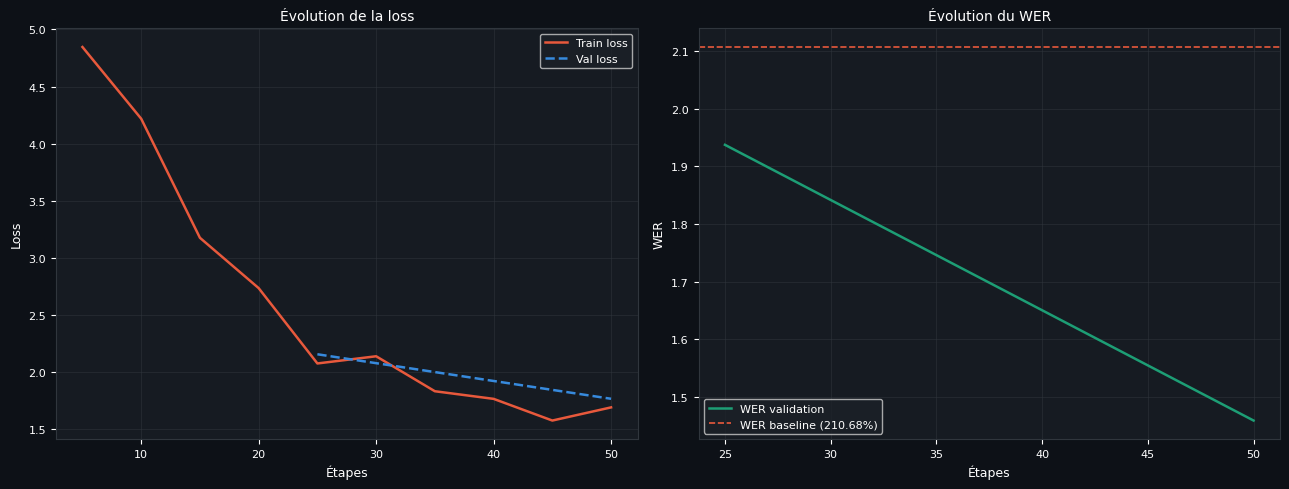

In [14]:
import matplotlib.pyplot as plt

logs       = trainer.state.log_history
train_logs = [l for l in logs if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in logs if "eval_loss" in l]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0D1117')

for ax in axes:
    ax.set_facecolor('#161B22')
    ax.tick_params(colors='white', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#30363D')
    ax.grid(True, color='#30363D', alpha=0.5)

# Loss
if train_logs:
    axes[0].plot([l["step"] for l in train_logs],
                  [l["loss"]  for l in train_logs],
                  color='#E8593C', linewidth=1.8, label="Train loss")
if eval_logs:
    axes[0].plot([l["step"]      for l in eval_logs],
                  [l["eval_loss"] for l in eval_logs],
                  color='#378ADD', linewidth=1.8, linestyle='--', label="Val loss")
axes[0].set_title("Évolution de la loss", color='white', fontsize=10)
axes[0].set_xlabel("Étapes", color='white', fontsize=9)
axes[0].set_ylabel("Loss",   color='white', fontsize=9)
axes[0].legend(facecolor='#1C2128', labelcolor='white', fontsize=8)

# WER
if eval_logs and "eval_wer" in eval_logs[0]:
    axes[1].plot([l["step"]     for l in eval_logs],
                  [l["eval_wer"] for l in eval_logs],
                  color='#1D9E75', linewidth=1.8, label="WER validation")
    axes[1].axhline(wer_baseline, color='#E8593C', linestyle='--',
                     linewidth=1.2, label=f"WER baseline ({wer_baseline:.2%})")
    axes[1].set_title("Évolution du WER", color='white', fontsize=10)
    axes[1].set_xlabel("Étapes",  color='white', fontsize=9)
    axes[1].set_ylabel("WER",     color='white', fontsize=9)
    axes[1].legend(facecolor='#1C2128', labelcolor='white', fontsize=8)

plt.tight_layout()
fig_path = os.path.join(BASE_DIR, "courbes_apprentissage.png")
plt.savefig(fig_path, facecolor='#0D1117', bbox_inches='tight', dpi=150)
print(f"Figure sauvegardée : {fig_path}")
plt.show()

## 13. Analyse des distinctions tonales
Le fongbé est tonal : le même mot avec ton H, B ou M a un sens différent.
On analyse si le fine-tuning améliore spécifiquement la reconnaissance selon le ton.

In [15]:
def detecter_ton_dominant(texte):
    """
    Détecte le ton dominant dans une transcription fongbé.
    H = accents aigus (á é í ó ú), B = accents graves (à è ì ò ù), M = sans diacritique.
    """
    if not isinstance(texte, str):
        return "M"
    hauts = len(re.findall(r'[\u00e1\u00e9\u00ed\u00f3\u00fa]', texte))
    bas   = len(re.findall(r'[\u00e0\u00e8\u00ec\u00f2\u00f9]', texte))
    if hauts == 0 and bas == 0:
        return "M"
    return "H" if hauts >= bas else "B"


# Récupérer predictions_baseline depuis JSON si nécessaire
try:
    _ = predictions_baseline
except NameError:
    data = json.load(open(os.path.join(BASE_DIR, "baseline_results.json")))
    predictions_baseline = data["predictions"]
    references_test      = data["references"]

transcriptions_test = references_test
tons = [detecter_ton_dominant(t) for t in transcriptions_test]

print(f"Distribution des tons dans le set de test :")
for t in ["H","B","M"]:
    n = tons.count(t)
    print(f"  Ton {t} : {n} utterances ({n/len(tons)*100:.0f}%)")

print(f"\n{'Ton':<6} {'N':<6} {'WER Baseline':>14} {'WER Fine-tuné':>14} {'Delta':>10}")
print("─" * 55)

for ton in ["H", "B", "M"]:
    indices = [i for i, t in enumerate(tons) if t == ton]
    if not indices:
        continue
    refs   = [transcriptions_test[i] for i in indices]
    p_base = [predictions_baseline[i] for i in indices]
    p_ft   = [predictions_ft[i]       for i in indices]

    # Filtrer références vides
    triplets = [(r,b,f) for r,b,f in zip(refs,p_base,p_ft) if r.strip()]
    if not triplets:
        continue

    wb = wer_metric.compute(predictions=[b for r,b,f in triplets],
                              references =[r for r,b,f in triplets])
    wf = wer_metric.compute(predictions=[f for r,b,f in triplets],
                              references =[r for r,b,f in triplets])
    delta = wb - wf
    signe = "↓" if delta > 0 else ("↑" if delta < 0 else "=")
    print(f"{ton:<6} {len(triplets):<6} {wb:>13.2%}  {wf:>13.2%}  {signe}{abs(delta):.2%}")

print("─" * 55)
print("↓ = amélioration après fine-tuning | ↑ = dégradation")

Distribution des tons dans le set de test :
  Ton H : 1 utterances (2%)
  Ton B : 5 utterances (8%)
  Ton M : 56 utterances (90%)

Ton    N        WER Baseline  WER Fine-tuné      Delta
───────────────────────────────────────────────────────
H      1             94.74%        100.00%  ↑5.26%
B      5            152.17%        240.00%  ↑87.83%
M      56           225.20%        228.29%  ↑3.09%
───────────────────────────────────────────────────────
↓ = amélioration après fine-tuning | ↑ = dégradation


## 14. Matrice de confusion des erreurs les plus fréquentes

In [16]:
from collections import Counter

def extraire_erreurs(predictions, references):
    erreurs = []
    for pred, ref in zip(predictions, references):
        mots_pred = str(pred).lower().split()
        mots_ref  = str(ref).lower().split()
        for i, mot_ref in enumerate(mots_ref):
            if i < len(mots_pred) and mots_pred[i] != mot_ref:
                erreurs.append((mot_ref, mots_pred[i]))
            elif i >= len(mots_pred):
                erreurs.append((mot_ref, "<suppression>"))
    return erreurs

erreurs_base = extraire_erreurs(predictions_baseline, transcriptions_test)
erreurs_ft   = extraire_erreurs(predictions_ft,       transcriptions_test)

print(f"Top 10 erreurs — Baseline ({len(erreurs_base)} erreurs totales) :")
for paire, count in Counter(erreurs_base).most_common(10):
    print(f"  '{paire[0]}' → '{paire[1]}' : {count}x")

print(f"\nTop 10 erreurs — Fine-tuné ({len(erreurs_ft)} erreurs totales) :")
for paire, count in Counter(erreurs_ft).most_common(10):
    print(f"  '{paire[0]}' → '{paire[1]}' : {count}x")

reduction = (len(erreurs_base) - len(erreurs_ft)) / len(erreurs_base) * 100 if erreurs_base else 0
print(f"\nRéduction du nombre d'erreurs : {reduction:.1f}%")

Top 10 erreurs — Baseline (736 erreurs totales) :
  'ɔ' → '<suppression>' : 14x
  'na' → '<suppression>' : 10x
  'ɖo' → '<suppression>' : 8x
  'e' → '<suppression>' : 6x
  'ɖie' → '<suppression>' : 6x
  'ma' → '<suppression>' : 6x
  'mi' → '<suppression>' : 6x
  'nu' → '<suppression>' : 6x
  'do' → '<suppression>' : 6x
  'ce' → '<suppression>' : 5x

Top 10 erreurs — Fine-tuné (731 erreurs totales) :
  'na' → '<suppression>' : 6x
  'ɖie' → '<suppression>' : 5x
  'a' → '<suppression>' : 5x
  'do' → '<suppression>' : 5x
  'nu' → '<suppression>' : 5x
  'wε' → '<suppression>' : 4x
  'ɔ' → '<suppression>' : 4x
  'ɖo' → '<suppression>' : 4x
  'e' → '<suppression>' : 4x
  'ce' → 'වු' : 4x

Réduction du nombre d'erreurs : 0.7%


## 15. Rapport final

In [17]:
from IPython.display import display, Markdown

# Calcul WER par ton pour le rapport
lignes_ton = ""
for ton in ["H", "B", "M"]:
    indices = [i for i, t in enumerate(tons) if t == ton]
    if not indices: continue
    refs = [transcriptions_test[i] for i in indices]
    pb   = [predictions_baseline[i] for i in indices]
    pf   = [predictions_ft[i]       for i in indices]
    triplets = [(r,b,f) for r,b,f in zip(refs,pb,pf) if r.strip()]
    if not triplets: continue
    wb = wer_metric.compute(predictions=[b for r,b,f in triplets], references=[r for r,b,f in triplets])
    wf = wer_metric.compute(predictions=[f for r,b,f in triplets], references=[r for r,b,f in triplets])
    lignes_ton += f"| {ton} | {len(triplets)} | {wb:.2%} | {wf:.2%} | {(wb-wf)/wb*100:+.1f}% |\n"

rapport_md = f"""
## Rapport Fine-tuning — Whisper Small / Fongbé

### Dataset
| Paramètre | Valeur |
|---|---|
| Audios utilisés | {len(df_selected)} |
| Durée totale | {df_selected['duration_sec'].sum()/60:.1f} min |
| Locuteurs | {df_selected['speaker_id'].nunique()} |
| Split train/test | {len(train_prepared)} / {len(test_prepared)} |

### Résultats WER
| Modèle | WER |
|---|---|
| Whisper small (baseline) | {wer_baseline:.2%} |
| Whisper small fine-tuné | {wer_ft:.2%} |
| **Amélioration** | **{amelioration:.1f}%** |

### WER par catégorie tonale
| Ton | N | Baseline | Fine-tuné | Δ |
|---|---|---|---|---|
{lignes_ton}
### Exemples de transcriptions
"""

for i in range(min(5, len(transcriptions_test))):
    rapport_md += f"""
**Exemple {i+1}** (Ton : {tons[i]})
- Référence  : *{transcriptions_test[i]}*
- Baseline   : {predictions_baseline[i]}
- Fine-tuné  : {predictions_ft[i]}
"""

display(Markdown(rapport_md))

# Sauvegarde CSV
df_rapport = pd.DataFrame({
    "reference":        transcriptions_test,
    "prediction_base":  predictions_baseline,
    "prediction_ft":    predictions_ft,
    "ton":              tons,
})
df_rapport.to_csv(os.path.join(BASE_DIR, "rapport_finetuning.csv"), index=False, encoding="utf-8-sig")
print(f"✅ Rapport CSV sauvegardé : {BASE_DIR}/rapport_finetuning.csv")


## Rapport Fine-tuning — Whisper Small / Fongbé

### Dataset
| Paramètre | Valeur |
|---|---|
| Audios utilisés | 307 |
| Durée totale | 29.9 min |
| Locuteurs | 13 |
| Split train/test | 245 / 62 |

### Résultats WER
| Modèle | WER |
|---|---|
| Whisper small (baseline) | 210.68% |
| Whisper small fine-tuné | 226.84% |
| **Amélioration** | **-7.7%** |

### WER par catégorie tonale
| Ton | N | Baseline | Fine-tuné | Δ |
|---|---|---|---|---|
| H | 1 | 94.74% | 100.00% | -5.6% |
| B | 5 | 152.17% | 240.00% | -57.7% |
| M | 56 | 225.20% | 228.29% | -1.4% |

### Exemples de transcriptions

**Exemple 1** (Ton : M)
- Référence  : *e gingin nεgbe do do wu e kanbyɔ mi ɖɔ hwetεnu tɔ ce na wa aji*
- Baseline   : e ging ging nen bero do, e cambia mi do hwe ten to chen nan waddi.
- Fine-tuné  : ε gingginε ngebe ɖo ɖo ɔ e kkanbɛε mi ɖɔxwe tε ɖi ɖo tse na waji

**Exemple 2** (Ton : M)
- Référence  : *e gu we e hεn gan ɔ gɔndɔn*
- Baseline   : Egoi Erengão, gondom
- Fine-tuné  : اي گو وي اي هنغاون جون دون

**Exemple 3** (Ton : M)
- Référence  : *sin gbe nε gbe ɔ e ɖazɔ wa wε myamya*
- Baseline   : ន្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្
- Fine-tuné  : sikbe nεge ɔ el ɖasonga wε nuja nuja

**Exemple 4** (Ton : M)
- Référence  : *un ɖo kwekwe ba na xɔ wε a e gbε ɖiɖɔ*
- Baseline   : ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន ន
- Fine-tuné  : Ḁ ɖo ɔ kɔ kεbɔ na xɔ wε a ɛ ɖe gbε ji ɖo

**Exemple 5** (Ton : M)
- Référence  : *e yi gbe nu ku e gudu wema ce lε bi*
- Baseline   : E yi benuku e gudu we matye lebi
- Fine-tuné  : ايقبنو كو اي گودو ويما چلب


✅ Rapport CSV sauvegardé : ./Fongbe_Speech_Dataset/rapport_finetuning.csv
